In [1]:
from pyomo.environ import (
    ConcreteModel, Set, RangeSet, Var, Param, Constraint, minimize,
    NonNegativeReals, sqrt, Objective, TransformationFactory,
    SolverFactory, value)
import matplotlib.pyplot as plt
from pyomo.dae import ContinuousSet, DerivativeVar
from pyomo_cvp import declare_profile, control_value
import pyomo_pounce 

Sets

$\mathcal{I} = \{1, 2, 3, 4\}$ tanks \
$\mathcal{K} = \{1, 2\}$ pumps

Parameters

$A_i$ tank cross-section area (cm²) \
$a_i$ tank outlet area (cm²) \
$x_i^{ss}$ steady-state level (cm) \
$u_k^{ss}$ steady-state pump flow (ml/s) \
$\gamma_k$ pump-$k$ flow-split ratio \
$x_i^L, x_i^U$ per-tank level bounds (cm) \
$T$ horizon (s), $\rho$ control-penalty weight, $g = 981$ cm/s²

Variables

$x_i(t)$ level in tank $i$ (cm) \
$u_k(t)$ pump-$k$ flow rate (ml/s) \
$z_i(t) = x_i(t) - x_i^{ss}$ level deviation \
$v_k(t) = u_k(t) - u_k^{ss}$ flow deviation

Objective

\begin{gather}
 \min_{x(\cdot),\, u(\cdot)} \int_0^T \left( \sum_{i \in \mathcal{I}} z_i(t)^2 + \rho \sum_{k \in \mathcal{K}} v_k(t)^2 \right) dt
\end{gather}

Subject to (mass balance with flow split through pump valves):

\begin{align}
 \dot{x}_1 &= -\tfrac{a_1}{A_1}\sqrt{2 g x_1} + \tfrac{a_3}{A_1}\sqrt{2 g x_3} + \tfrac{\gamma_1}{A_1} u_1 \\
 \dot{x}_2 &= -\tfrac{a_2}{A_2}\sqrt{2 g x_2} + \tfrac{a_4}{A_2}\sqrt{2 g x_4} + \tfrac{\gamma_2}{A_2} u_2 \\
 \dot{x}_3 &= -\tfrac{a_3}{A_3}\sqrt{2 g x_3} + \tfrac{1 - \gamma_2}{A_3} u_2 \\
 \dot{x}_4 &= -\tfrac{a_4}{A_4}\sqrt{2 g x_4} + \tfrac{1 - \gamma_1}{A_4} u_1
\end{align}

with initial condition $x_i(0) = x_i^0$ (from the app sidebar), pump bounds $0 \le u_k(t) \le 60$ ml/s, and level bounds $x_i^L \le x_i(t) \le x_i^U$.

Solved by simultaneous direct transcription with orthogonal collocation on finite elements (Radau-IIA, 3 collocation points per element). The resulting NLP is handed to rIPOPT.

In [2]:
#Define the model
m = ConcreteModel()


# ── Discretisation ─────────────────────────────────────────────────────────────
# The optimal control problem is solved via direct collocation (Radau IIA, 3-point).
# The time horizon [0, N*h] = [0, 150 s] is divided into N finite elements,
# each of length h = 10 s, with ncp = 3 internal collocation points per element.

#sets
N = 15  # Number of finite elements
m.i = ContinuousSet(initialize=RangeSet(0,N))
m.t = Set(initialize=RangeSet(1,4)) # Set of tanks

# ── Variables ──────────────────────────────────────────────────────────────────
# All state variables are expressed as DEVIATIONS from steady state (z = x - x_ss).
# This formulation simplifies the objective and boundary conditions.

#variables

# z_k[i,c]: state of tank k at collocation point c within element i
# Bounds enforce physical height limits (z = x - x_ss, so bounds = [x_min - x_ss, x_max - x_ss])
m.z1 = Var(m.i, bounds = (-6.5,14))
m.z2 = Var(m.i, bounds = (-6.5,14))
m.z3 = Var(m.i, bounds = (-10.7,13.8))
m.z4 = Var(m.i, bounds = (-16.8,6.7))

m.z1dot = Var(m.i)
m.z2dot = Var(m.i)
m.z3dot = Var(m.i)
m.z4dot = Var(m.i)


# v_k[i]: control input DEVIATION from steady state in element i (u_k = v_k + u_ss_k)
# Bounds correspond to allowable pump flow deviations (ml/s)
m.v1 = Var(m.i,bounds = (-43.4,16.6))
declare_profile(m.v1, wrt=m.i, profile="piecewise_constant")
m.v2 = Var(m.i, bounds = (-35.4,24.6))
declare_profile(m.v2, wrt=m.i, profile="piecewise_constant")

# Scalar tracking variable — holds the summed squared deviations (the objective value)
m.track = Var(within=NonNegativeReals)

# ── Parameters ─────────────────────────────────────────────────────────────────

#parameters
m.smalla = Param(m.t, initialize = {1: .233, 2: .242, 3: .127, 4: .127})   # Drain nozzle areas a_k (cm²)
m.biga = Param(m.t, initialize = {1: 50.27, 2: 50.27, 3: 28.27, 4: 28.27}) # Tank cross-sections A_k (cm²)
m.xss = Param(m.t, initialize = {1: 14, 2: 14, 3: 14.2, 4: 21.3})          # Steady-state heights x_ss (cm)
m.uss = Param(RangeSet(1,2), initialize = {1: 43.4, 2: 35.4})           # Steady-state pump flows u_ss (ml/s)
m.g = Param(initialize = 981)     # Gravitational acceleration (cm/s²)
m.gamma = Param(initialize = .4)  # Flow split fraction: γ to lower tank, (1-γ) to upper tank
m.h = Param(initialize = 10)      # Finite element length (s); total horizon = N*h = 150 s


# Initial conditions — deviation from steady state at t=0 (cm)
m.z1init = Param(initialize = 5)
m.z2init = Param(initialize = -5)
m.z3init = Param(initialize = 5)
m.z4init = Param(initialize = -5)

# ── Differential equations (ODEs evaluated at each collocation point) ──────────
# Torricelli drain law + pump inflow, written in deviation form:
#   A_k * dz_k/dt = -a_k*sqrt(2g*(z_k + x_ss_k)) + inflows
#
# Tank 1 (lower-left): drains via nozzle a1, receives γ*u1 from pump 1 and outflow from Tank 3
# Tank 2 (lower-right): drains via nozzle a2, receives γ*u2 from pump 2 and outflow from Tank 4
# Tank 3 (upper-left): drains via nozzle a3 into Tank 1, receives (1-γ)*u2 from pump 2
# Tank 4 (upper-right): drains via nozzle a4 into Tank 2, receives (1-γ)*u1 from pump 1

#differential equations

@m.Constraint(m.i)
def z1dot_def(m,i): 
    return m.z1dot[i] == -(m.smalla[1]/m.biga[1])*sqrt(2*m.g*(m.z1[i]+m.xss[1]))+(m.smalla[3]/m.biga[1])*sqrt(2*m.g*(m.z3[i]+m.xss[3]))+(m.gamma/m.biga[1])*(m.v1[i]+m.uss[1]) 

@m.Constraint(m.i)
def z2dot_def(m,i): 
    return m.z2dot[i] == -(m.smalla[2]/m.biga[2])*sqrt(2*m.g*(m.z2[i]+m.xss[2]))+(m.smalla[4]/m.biga[2])*sqrt(2*m.g*(m.z4[i]+m.xss[4]))+(m.gamma/m.biga[2])*(m.v2[i]+m.uss[2]) 

@m.Constraint(m.i)
def z3dot_def(m,i): 
    return m.z3dot[i] == -(m.smalla[3]/m.biga[3])*sqrt(2*m.g*(m.z3[i]+m.xss[3]))+((1-m.gamma)/m.biga[3])*(m.v2[i]+m.uss[2])

@m.Constraint(m.i)
def z4dot_def(m,i):
    return m.z4dot[i] == -(m.smalla[4]/m.biga[4])*sqrt(2*m.g*(m.z4[i]+m.xss[4]))+((1-m.gamma)/m.biga[4])*(m.v1[i]+m.uss[1])

# ── Initial conditions ─────────────────────────────────────────────────────────
# Fix the element-start value at t=0 to the specified initial deviation.
@m.Constraint()
def z1init_def(m):
    return m.z1[0] == m.z1init

@m.Constraint()
def z2init_def(m):
    return m.z2[0] == m.z2init

@m.Constraint()
def z3init_def(m):
    return m.z3[0] == m.z3init


@m.Constraint()
def z4init_def(m):
    return m.z4[0] == m.z4init


# ── Objective ──────────────────────────────────────────────────────────────────
# Minimise the sum of squared state deviations over all breakpoints (integral tracking cost).
# track = Σ_{i=0}^{N} (z10[i]² + z20[i]² + z30[i]² + z40[i]²)
@m.Constraint()
def tracking_def(m):
    return m.track == sum(m.z1[i]**2 + m.z2[i]**2 + m.z3[i]**2 + m.z4[i]**2 for i in m.i)

m.obj = Objective(expr = m.track, sense = minimize)

In [3]:
# Solve the NLP with ripopt — a Rust reimplementation of IPOPT.
# The solver binary is bundled in the `pyomo-ripopt` wheel, so no
# system-level install is needed; SolverFactory finds it automatically.
# tee=True streams the full solver log to stdout.
TransformationFactory("dae.collocation").apply_to(
    m, nfe=N, ncp=3, scheme="LAGRANGE-RADAU")
TransformationFactory("cvp.parameterize").apply_to(m)
solver = SolverFactory('pounce')
solver.solve(m,tee=True)

pounce: wrote C:\Users\Devin\AppData\Local\Temp\tmpilznq84a.pyomo.sol


Reading C:\Users\Devin\AppData\Local\Temp\tmpilznq84a.pyomo.nl...
Parsed 399 vars, 189 cons, jac_nnz=713, h_nnz=184 in 0.02s
******************************************************************************
This program contains POUNCE, a Rust port of Ipopt for nonlinear optimization.
 Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
******************************************************************************

This is POUNCE version 0.2.0, running with linear solver FERAL.

Number of nonzeros in equality constraint Jacobian...:      713
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:      184

Total number of variables............................:      399
                     variables with only lower bounds:        1
                variables with lower and upper bounds:      214
                     variables w

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 189, 'Number of variables': 399, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'POUNCE 0.2.0\\x3a SolveSucceeded', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 0.4371602535247803}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

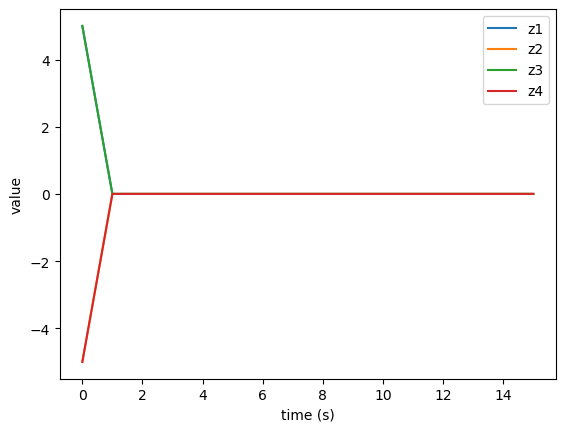

In [4]:
# Extract optimal state trajectories at the breakpoints (N+1 values, one per element boundary)
# m.iii = [0, 1, ..., N]; multiply by m.h.value to convert element indices to time in seconds.

t = m.i.get_finite_elements()          # after discretization

z1 = [value(m.z1[i]) for i in t]
z2 = [value(m.z2[i]) for i in t]
z3 = [value(m.z3[i]) for i in t]
z4 = [value(m.z4[i]) for i in t]

# Plot optimal state trajectories (deviations from steady state, cm)
plt.plot(t, z1, label='z1')
plt.plot(t, z2, label='z2')
plt.plot(t, z3, label='z3')
plt.plot(t, z4, label='z4')

plt.xlabel('time (s)')
plt.ylabel('value')
plt.legend()
plt.show()

In [5]:
t

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

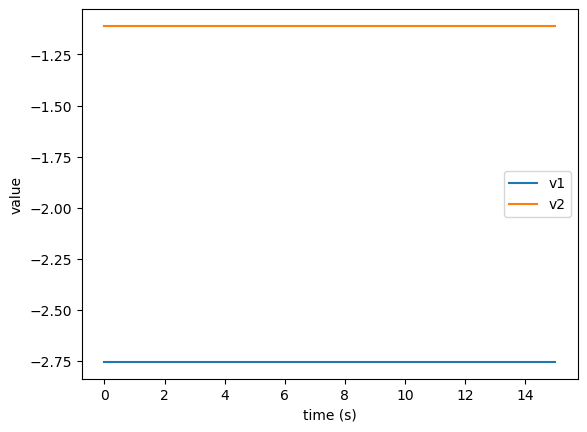

In [6]:
# Extract optimal control inputs (N values, one piecewise-constant value per
# finite element, indexed by the element's START time).
# m.i = [0, 1, ..., N]; multiply by m.h.value to convert to time in seconds.

t = m.i.get_finite_elements()

v1 = [value(m.v1[i]) for i in t[:-1]]
v2 = [value(m.v2[i]) for i in t[:-1]]

# Plot optimal control trajectories (deviations from steady-state pump flows,
# ml/s) as steps: each value holds over the element it starts.
plt.figure()
plt.step(t, v1 + v1[-1:], where='post', label='v1')
plt.step(t, v2 + v2[-1:], where='post', label='v2')

plt.xlabel('time (s)')
plt.ylabel('value')
plt.legend()
plt.show()


In [7]:
v1

[-2.755026431754606,
 -2.755026431754606,
 -2.755026431754606,
 -2.755026431754606,
 -2.755026431754606,
 -2.755026431754606,
 -2.755026431754606,
 -2.755026431754606,
 -2.755026431754606,
 -2.755026431754606,
 -2.755026431754606,
 -2.755026431754606,
 -2.755026431754606,
 -2.755026431754606,
 -2.755026431754606]